# Введение

## Цель работы
Изучение алгоритмов кластеризации, приобретение навыков оценки качества разбиения данных на кластеры и интерпретации результатов.

## Постановка задачи

1. Загрузить датасет для задачи кластеризации / классификации (например, с платформы Kaggle). Провести дескриптивный анализ данных: определить размерность, типы признаков, наличие пропусков. Оценить распределение переменных (близость к нормальному) с использованием визуализации (гистограммы). Проверить условие применения кластеризации: отсутствие классов, осмысленность кластеризации, отсутствие выбросов.

2. Выполнить стандартизацию / нормализацию числовых признаков. Обосновать выбор метода масштабирования. Построить матрицу диаграмм рассеивания для визуальной оценки структуры данных, предположительного количества кластеров и типа кластерной структуры. Аргументировать выбор методов кластеризации на основе формы, размера и плотности кластеров.

3. Реализовать кластеризацию двумя различными методами на выбор: K-means (K-средних); иерархическая кластеризация; DBSCAN; EM-алгоритм (Gaussian Mixture). Для методов, требующих задания числа кластеров (K-means, иерархическая), подобрать оптимальное значение k с использованием: метода локтя и / или анализа силуэта.

4. Рассчитать метрики качества для обоих методов: внутренние и внешние. Оценить расстояние между кластерами, внутрикластерные расстояния, компактность кластеров, центры кластеров. Опционально, если известно разделение на классы, посчитать: индекс Rand, индекс Жаккара и др. внешние метрики. Привести содержательную интерпретацию полученных значений.

5. Исследовать влияние параметров одного из методов (например, ε и min_samples для DBSCAN или количества кластеров k для K-means) на качество кластеризации.

6. Визуализировать полученные кластеры в пространстве признаков (использовать PCA для снижения размерности при необходимости). Проанализировать центры кластеров (для K-means) и дать содержательную интерпретацию выделенных групп. Сравнить результаты, полученные двумя разными методами.

# Описание датасета

Для работы выбран датасет [Dry Bean](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset). 

Датасет описывает морфологические признаки семян сухой фасоли 7 сортов, полученные на основе изображений. Вешне сорта фасоли очень похожи и при ручной сортировке возможны ошибки, поэтому целью работы будет выявление группы таких признаков для автоматизации опредления сорта.

С помощью системы компьютерного зрения были получены фотографии 13 611 зёрен фасоли (7 сортов). Из изображений после этапов сегментации и выделения контуров извлечены 16 признаков, описывающих форму и геометрию зерна:
| Признак             | Роль    | Тип переменной | Описание (рус.)                                                                                    |
| ------------------- | ------- | ---------------| -------------------------------------------------------------------------------------------------- |
| **Area**            | признак | целочисленный  | Площадь зерна (количество пикселей внутри контура боба)                                            |
| **Perimeter**       | признак | вещественный   | Периметр зерна — длина границы контура                                                             |
| **MajorAxisLength** | признак | вещественный   | Длина главной оси эллипса, аппроксимирующего зерно (самая длинная линия через зерно)               |
| **MinorAxisLength** | признак | вещественный   | Длина малой оси эллипса (максимальная линия, перпендикулярная главной оси)                         |
| **AspectRatio**     | признак | вещественный   | Отношение MajorAxisLength к MinorAxisLength (вытянутость формы)                                    |
| **Eccentricity**    | признак | вещественный   | Эксцентриситет эллипса с такими же моментами, как у области зерна                                  |
| **ConvexArea**      | признак | целочисленный  | Площадь выпуклой оболочки: число пикселей в минимальном выпуклом многоугольнике, покрывающем зерно |
| **EquivDiameter**   | признак | вещественный   | Эквивалентный диаметр — диаметр круга с той же площадью, что и зерно                               |
| **Extent**          | признак | вещественный   | Доля площади зерна в его ограничивающем прямоугольнике (bounding box)                              |
| **Solidity**        | признак | вещественный   | Плотность/выпуклость: отношение Area к ConvexArea                                                  |
| **Roundness**       | признак | вещественный   | Округлость, вычисляется как ( \frac{4\pi A}{P^2} )                                                 |
| **Compactness**     | признак | вещественный   | Компактность (мера близости формы к кругу)                                                         |
| **ShapeFactor1**    | признак | вещественный   | Фактор формы 1                                                                                     |
| **ShapeFactor2**    | признак | вещественный   | Фактор формы 2                                                                                     |
| **ShapeFactor3**    | признак | вещественный   | Фактор формы 3                                                                                     |
| **ShapeFactor4**    | признак | вещественный   | Фактор формы 4                                                                                     |
| **Class**           | целевая | категориальный | Сорт фасоли: Seker, Barbunya, Bombay, Cali, Dermosan, Horoz, Sira                                  |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



df = pd.read_excel("Dry_Bean_Dataset.xlsx")
df.head()


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


Из датасета мы сразу уберем метку класса - признак Class. Но в конце будем его использовать для анализа полученных результатов.

In [65]:
y = df["Class"]
df = df.drop(columns=["Class"])
n = df.shape[0]

missing_per_col = df.isna().sum()
print("\nВсего пропусков в датасете:", missing_per_col.sum())
print("\nКоличество записей в датасете:", missing_per_col.sum())



Всего пропусков в датасете: 0

Количество записей в датасете: 0


Как мы видим в датасете отсутвуют пропуски.

# Дескриптивный анализ

,Признак,Среднее,Медиана,Мода,Минимум,Максимум,Стандартное отклонение,Дисперсия,Асимметрия,Эксцесс,Оценка нормальности распредления (тест Колмагорова-Смирнова)
0,Area,53048.28,44652.00,28122.00,20420.00,254616.00,29324.10,8.599026e+08,2.95,10.80,p=0.000e+00 → Далеко от нормального
1,Perimeter,855.28,794.94,683.34,524.74,1985.37,214.29,4.592007e+04,1.63,3.59,p=3.633e-166 → Далеко от нормального
2,MajorAxisLength,320.14,296.88,277.37,183.60,738.86,85.69,7.343490e+03,1.36,2.53,p=1.661e-136 → Далеко от нормального
3,MinorAxisLength,202.27,192.43,154.31,122.51,460.20,44.97,2.022310e+03,2.24,6.65,p=3.647e-287 → Далеко от нормального
4,AspectRation,1.58,1.55,1.70,1.02,2.43,0.25,6.000000e-02,0.58,0.11,p=1.075e-66 → Далеко от нормального
5,Eccentricity,0.75,0.76,0.81,0.22,0.91,0.09,1.000000e-02,-1.06,1.39,p=5.551e-136 → Далеко от нормального
6,ConvexArea,53768.20,45178.00,37023.00,20684.00,263261.00,29774.92,8.865456e+08,2.94,10.74,p=0.000e+00 → Далеко от нормального
7,EquivDiameter,253.06,238.44,189.22,161.24,569.37,59.18,3.501930e+03,1.95,5.19,p=2.368e-182 → Далеко от нормального
8,Extent,0.75,0.76,0.59,0.56,0.87,0.05,0.000000e+00,-0.90,0.64,p=6.026e-81 → Далеко от нормального
9,Solidity,0.99,0.99,0.96,0.92,0.99,0.00,0.000000e+00,-2.55,12.80,p=5.604e-227 → Далеко от нормального


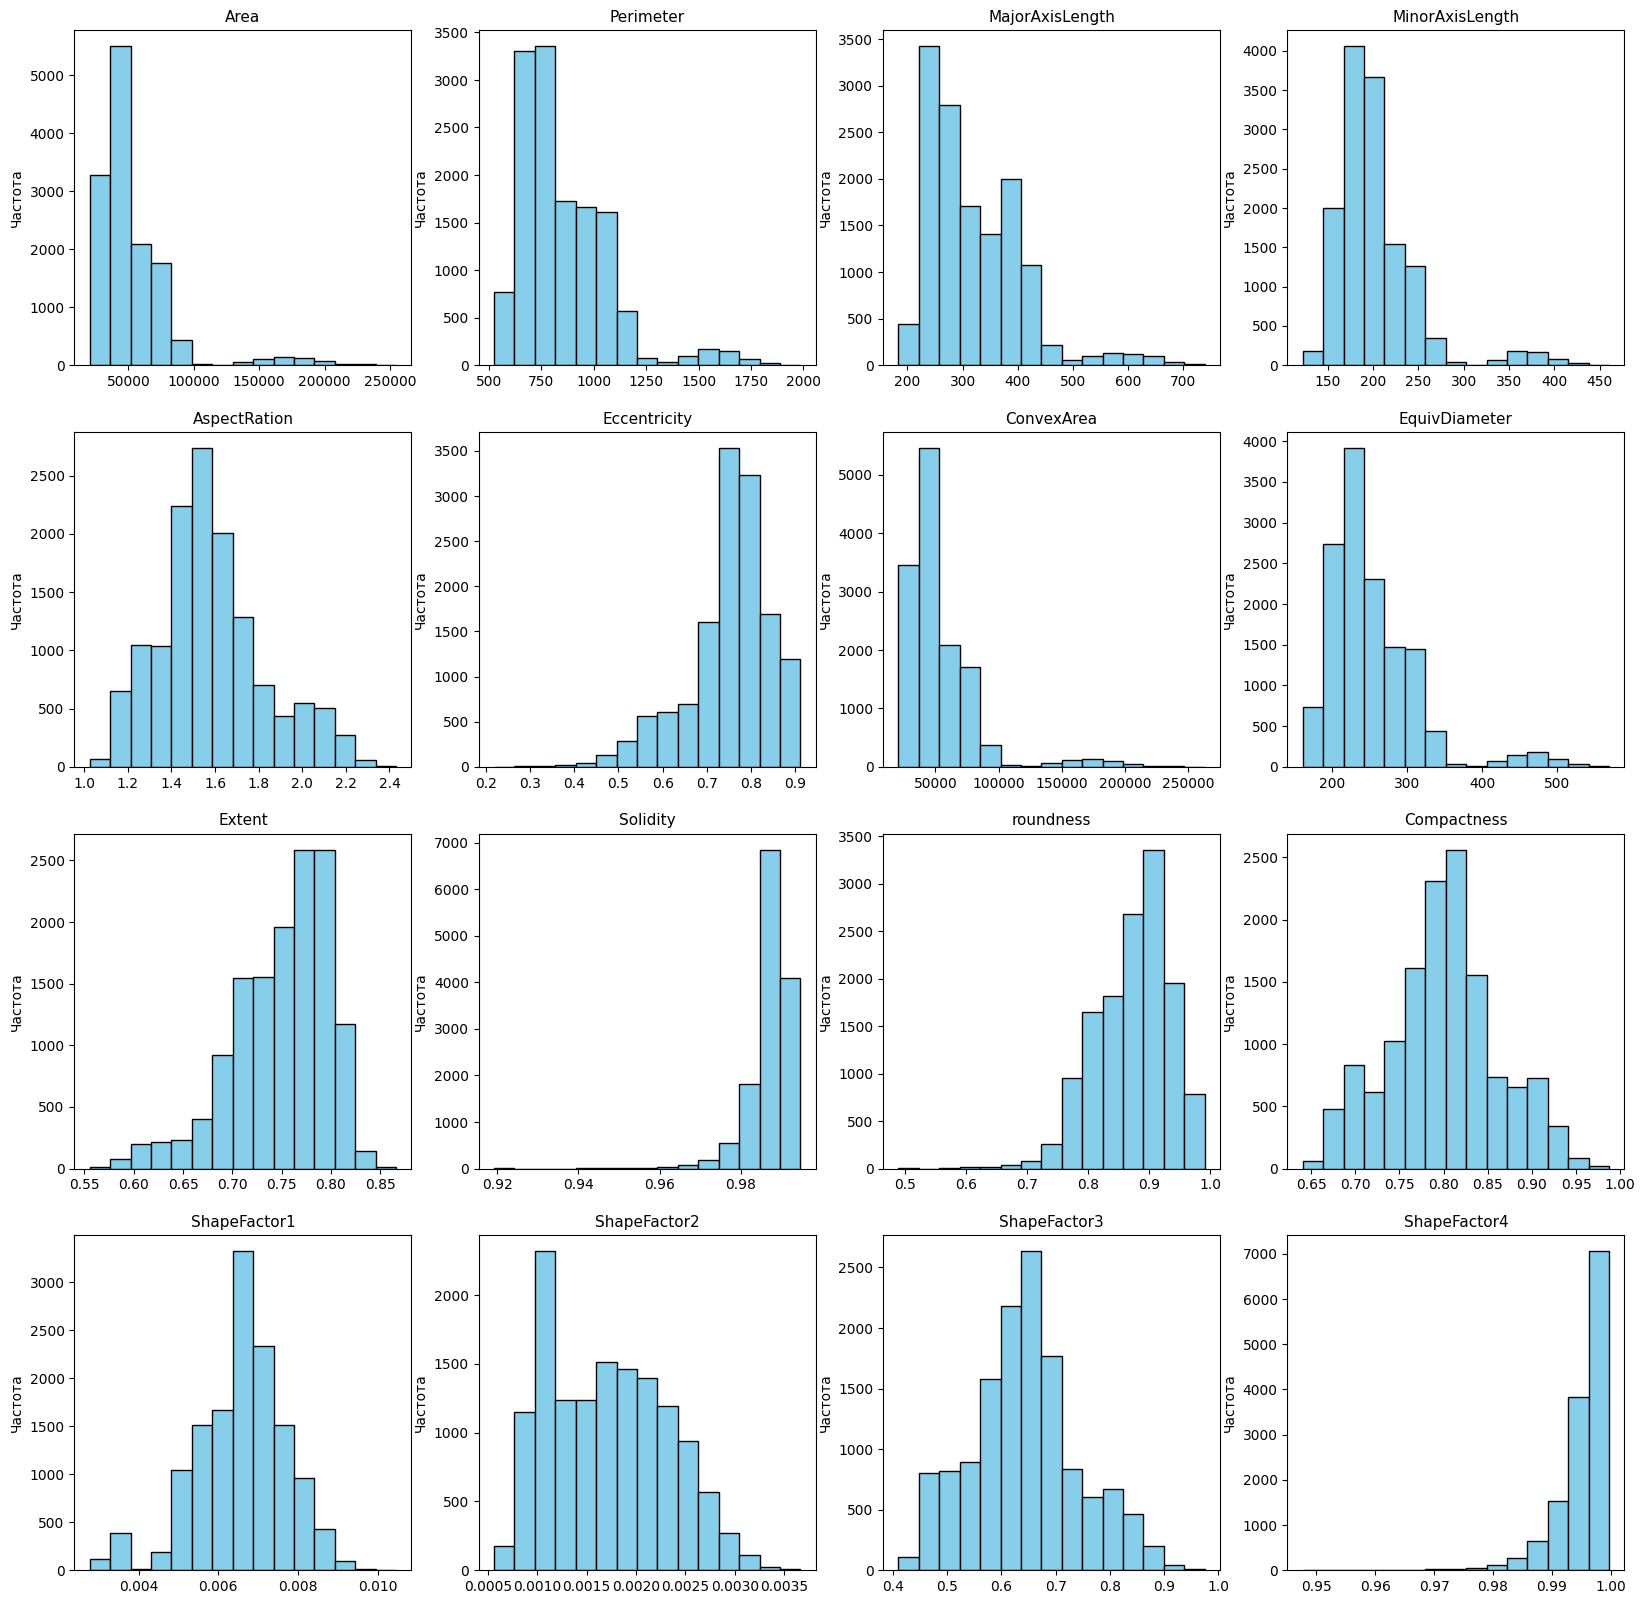

In [72]:

k = int(math.ceil(1 + math.log2(n)))

def interpret_pvalue(p):
     if p > 0.05:
         return "Нормальное"
     elif p > 0.01:
         return "Близко к нормальному"
     else:
         return "Далеко от нормального"
     
features = df.columns
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

stat = {
    "Признак": [], "Среднее": [], "Медиана": [], "Мода": [], "Минимум": [], "Максимум": [],
    "Стандартное отклонение": [], "Дисперсия": [], "Асимметрия": [], "Эксцесс": [],
    "Оценка нормальности распредления (тест Колмагорова-Смирнова)": []
    }

for i, feature in enumerate(features):
    ks_test = stats.kstest(df[feature], 'norm', args=(df[feature].mean(), df[feature].std()))

    stat["Признак"].append(feature)
    stat["Среднее"].append(round(df[feature].mean(), 2))
    stat["Медиана"].append(round(df[feature].median(), 2))
    stat["Мода"].append(round(df[feature].mode()[0], 2))
    stat["Минимум"].append(round(df[feature].min(), 2))
    stat["Максимум"].append(round(df[feature].max(), 2))
    stat["Стандартное отклонение"].append(round(df[feature].std(), 2))
    stat["Дисперсия"].append(round(df[feature].var(), 2))
    stat["Асимметрия"].append(round(df[feature].skew(), 2))
    stat["Эксцесс"].append(round(df[feature].kurtosis(), 2))
    stat["Оценка нормальности распредления (тест Колмагорова-Смирнова)"].append(f"p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}")


    axes[i].hist(df[feature], bins=k_, edgecolor='black', color='skyblue')
    axes[i].set_title(feature, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Частота")

display(pd.DataFrame(stat))

## TODO: Анализ добавь

## Матрица корреляции

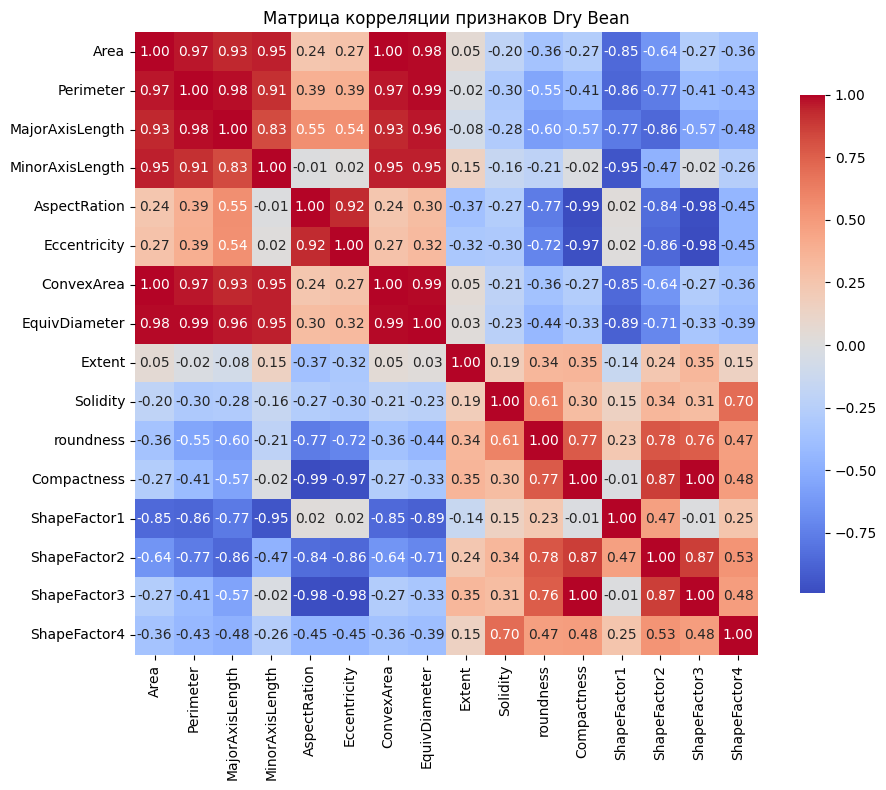

In [ ]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Матрица корреляции признаков Dry Bean")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


На матрице корреляции видим очень много корелирующих между собой признаков. Это не удвительно т.к. многие математически выражаются друг через друга. Можно выделить две основые группы колерирующих признаков:
1. Признаки определющие размер боба
    - Area
    - Perimeter
    - MajorAxisLength
    - MinorAxisLength
    - ConvexArea
    - EquivDiameter
1. Признаки определющие форму боба
    - AspectRation
    - Eccentricity
    - Compactness

При этом остальные признаки тоже имеют большую корреляцию. Отсюда наблюдаем что нет каких определенных пар признаков и не получится провести отбор признаков просто "выкинув" ненужные. При этом по матрице также можно сделать вывод что есть определенные группы признаков. В связи с этим проведем факторный анализ.

# Факторный анализ

## Стандартизация признаков

Перед стандаритизацией посмотрим на диаграммы ящика с усами для анализа наличия выбросов

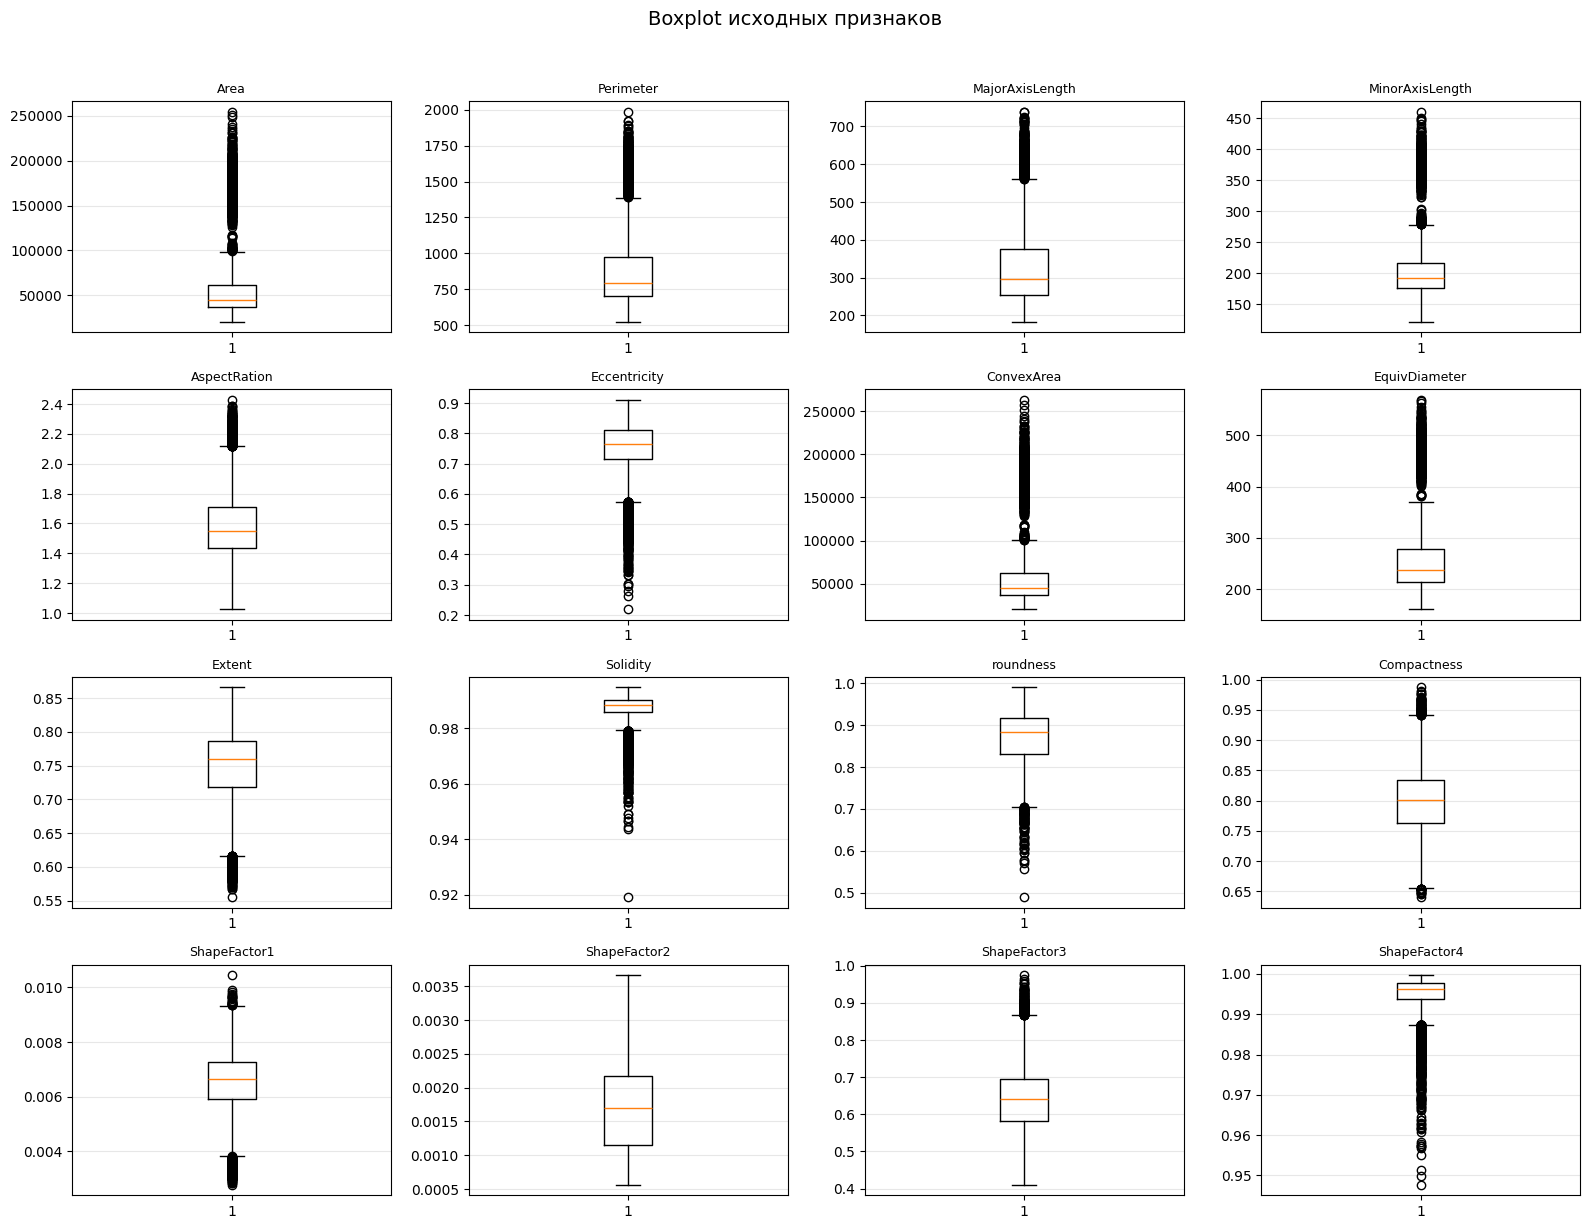

In [108]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col, fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Boxplot исходных признаков", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


По диаграммам видим довольно большое количество выбросов. Есть признаки и с плотными группами выбросов (например Area), так и признаки у которых есть одиночные выбросы (например Solidity). В связи с этим для стандартизации будем использовать RobustScaler, который хорошо справлятся с выбросами

In [109]:
X = df.copy()
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

## Оценка уместности проведения факторного анализа

In [ ]:
kmo_all, kmo_model = calculate_kmo(X_scaled)
print(f"KMO по модели: {kmo_model:.3f}") 

chi_square_value, p_value = calculate_bartlett_sphericity(X_scaled)
print(f"Тест Бартлетта: χ²={chi_square_value:.2f}, p-value={p_value:.3e}")

KMO по модели: 0.665
Тест Бартлетта: χ²=1046464.33, p-value=0.000e+00


c:\Users\bulch\Desktop\Нейронки\ML\.venv\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


- KMO показывавает средний результат, корреляционная структура признаков достаточно выражена, чтобы факторный анализ имел смысл.
- Тест Бартлетта показывает что корреляционная матрица существенно отличается от единичной, между признаками есть статистически значимые связи, а значит факторный анализ допустим и имеет смысл.

Обе оценки показывают что факторный анализ имеет смысл в нашем случае.

## Оценка количества факторов

c:\Users\bulch\Desktop\Нейронки\ML\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Первые собственные значения:
Фактор 1: λ = 8.875
Фактор 2: λ = 4.229
Фактор 3: λ = 1.281
Фактор 4: λ = 0.818
Фактор 5: λ = 0.438
Фактор 6: λ = 0.184
Фактор 7: λ = 0.112
Фактор 8: λ = 0.052
Фактор 9: λ = 0.008
Фактор 10: λ = 0.001


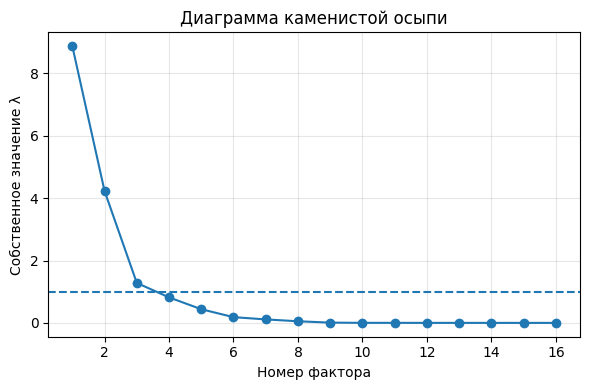

In [115]:
fa_full = FactorAnalyzer(n_factors=X.shape[1], rotation=None, method='principal')
fa_full.fit(X_scaled)

ev, v = fa_full.get_eigenvalues()

print("\nПервые собственные значения:")
for i, val in enumerate(ev[:10], start=1):
    print(f"Фактор {i}: λ = {val:.3f}")

plt.figure(figsize=(6,4))
plt.plot(range(1, len(ev)+1), ev, marker='o')
plt.axhline(1, linestyle='--')
plt.title("Диаграмма каменистой осыпи")
plt.xlabel("Номер фактора")
plt.ylabel("Собственное значение λ")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- По критерию Кайзера факторы у которых λ < 1 отсекаются. Он показывает что нужно взять 3 фактора.
- Анализируя диаграмму каменистой осыпи так же приходим к выводу что фактора 3. Переходы 1 -> 2 и 2 -> 3 имеют очень крутой угл наклона, наклон 3 -> 4 уже ближе к прямой.

Исходя из критериz Кайзера и анализа диаграммы каменистой осыпи приходим к выводу о налиции 3-х факторов.

c:\Users\bulch\Desktop\Нейронки\ML\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\bulch\Desktop\Нейронки\ML\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


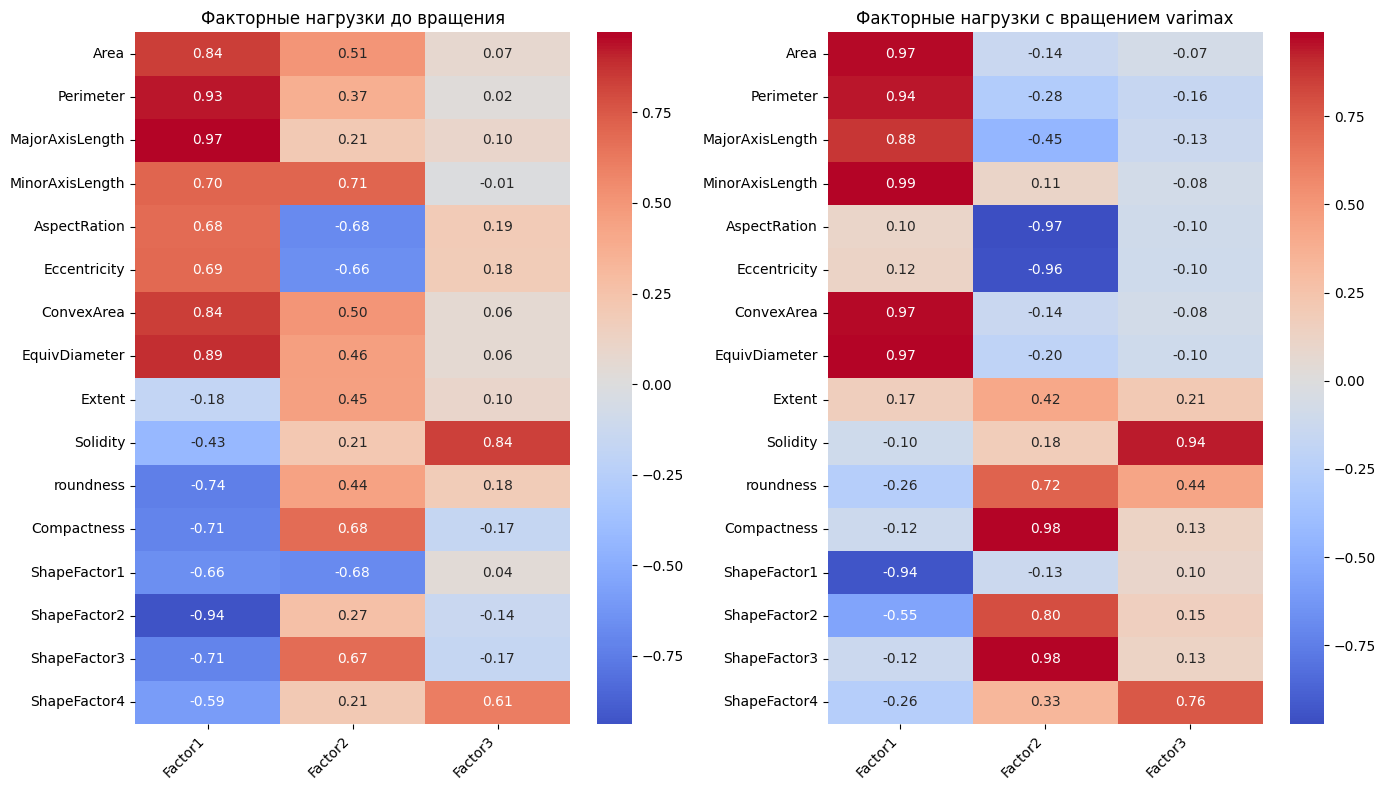

In [120]:
from factor_analyzer import FactorAnalyzer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

n_factors = 3

# До вращения
fa_no_rot = FactorAnalyzer(
    n_factors=n_factors,
    rotation=None,
    method='principal'
)
fa_no_rot.fit(X_scaled)

loadings_no_rot = pd.DataFrame(
    fa_no_rot.loadings_,
    index=X.columns,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

# После вращения
fa_varimax = FactorAnalyzer(
    n_factors=n_factors,
    rotation='varimax',
    method='principal'
)
fa_varimax.fit(X_scaled)

loadings_varimax = pd.DataFrame(
    fa_varimax.loadings_,
    index=X.columns,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

plt.figure(figsize=(14, 8))

plt.subplot(1, 2, 1)
sns.heatmap(loadings_no_rot, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Факторные нагрузки до вращения")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)


plt.subplot(1, 2, 2)
sns.heatmap(loadings_varimax, annot=True, fmt=".2f", cmap="coolwarm", center=0 )
plt.title("Факторные нагрузки с вращением varimax")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


- До вращения многие признаки "размазаны" по нескольким факторам.
- После почти каждый признак сосредоточен в одном факторе. 

Попробуем сделать анализ полученных факторов:
- Factor 1
    - Имеет сильные положительные кореляции с Area, ConvexArea, EquivDiameter, Perimeter, MajorAxisLength, MinorAxisLength. 
    - А также сильную отрицательную с ShapeFactor1 и умеренную ShapeFactor2.
    - Т.е. чем боб крупнее, тем выше Factor1.
    - **Интерпретация**: Общий размер зерна
- Factor 2
    - Имеет сильные положительные кореляции с roundness, Compactness, ShapeFactor2, ShapeFactor3.
    - А также сильную отрицательную с AspectRation, Eccentricity.
    - Т.е. если зерно вытянутое, эксцентричное - Factor2 отрицателен, если круглое и компактное - Factor2 положителен.
    - **Интерпретация**: Форма (округлость - вытянутость) зерна
- Factor3
    - Имеет сильные положительные кореляции с Solidity, ShapeFactor4 и умеренные с roundness, Extent.
    - Т.е. чем плотнее и “заполненнее” объект внутри ограничивающего прямоугольника, чем меньше “дыр” и неровностей по границе, тем Factor3 больше.
    - **Интерпретация**: Заполненность/гладкость контура зерна


Факторный анализ выявил 3 объяснимых фактора, по которым мы сможем провести класторизацию.


# Диаграммы рассеивания

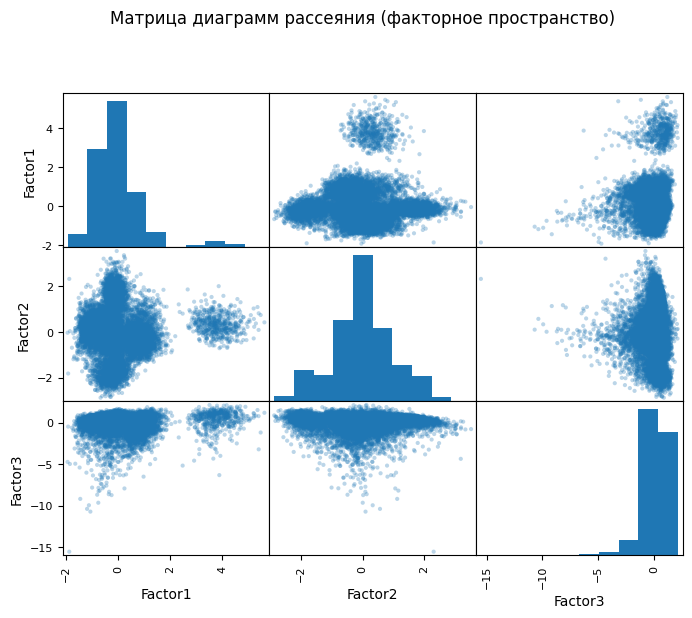

<Figure size 800x600 with 0 Axes>

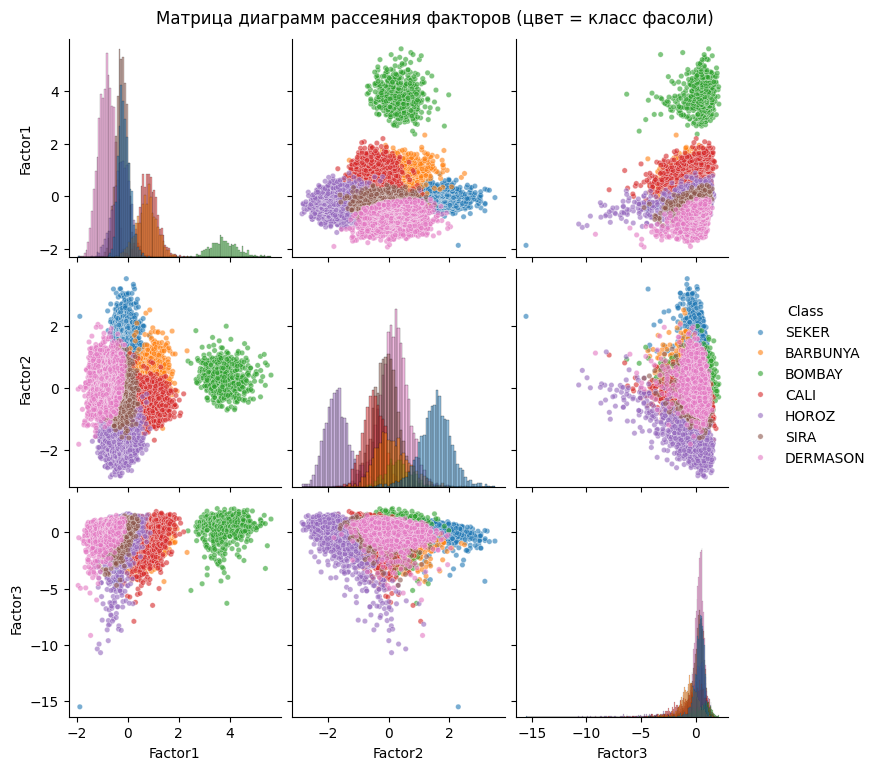

In [126]:
# Диаграммы рассеивания
df_plot = df_factors.copy()

pd.plotting.scatter_matrix(
    df_plot[["Factor1", "Factor2", "Factor3"]],
    figsize=(8, 6),
    diagonal="hist",
    alpha=0.3
)
plt.suptitle("Матрица диаграмм рассеяния (факторное пространство)", y=1.02)
plt.show()

# Диаграммы рассеивания с метками классов
df_plot = df_factors.copy()
df_plot["Class"] = y.values

plt.figure(figsize=(8, 6))
sns.pairplot(
    data=df_plot,
    vars=["Factor1", "Factor2", "Factor3"],
    hue="Class",
    diag_kind="hist",
    plot_kws={"alpha": 0.6, "s": 15}
)
plt.suptitle("Матрица диаграмм рассеяния факторов (цвет = класс фасоли)", y=1.02)
plt.show()


По диаграмам видно несколько (≈5–7) сгущений
- одно крупное облако “очень больших зёрен”
- одно-два облака средних по размеру, но различающихся по форме
- одно-два облака мелких/более вытянутых зёрен

И переходные области

По класторезированным диаграммам так же наблюдаем что очень хорошо отделяется класс BOMBAY, остальные классы также неплохо отделяются, но немного перекрывают друг друга.
Factor 1 и Factor 2 (размер и округлость соответвенно) лучше всего разделяют зерна, Factor 3 хуже, на диаграммах с ним много перекрытий.

Можно сделать вывод что получится около 5-7 кластеров, некоторые сорта зерен похожи друг на друга, и маловероятно что получится 7 идеальных кластеров. 

Так же можно сделать следующие выводы:
- кластеры компактные, эллипсоидные
- плотность внутри кластеров примерно однородная
- сильных “цепочек”, иерархий “кластер в кластере” нет.

Из этого следует:
- Подходят методы, которые предполагают выпуклые/эллипсоидные кластеры в евклидовом пространстве:
    - k-means (центроидный метод),
    - Gaussian Mixture (EM),
    - агломеративная иерархическая кластеризация с критерием Ward.

- Менее естественны для этих данных:
    - DBSCAN и другие плотностные методы (здесь нет кластеров сложной формы с сильно разной плотностью)

При этом иерархическая кластеризация с критерием Ward нам подойдет хуже, т.к. в наших данных выраженной иерархии нет. А так же его лучше отсечь из-за объема данных.

На основе анализа диаграмм рассивания приходим к выводу что класторизации лучше всего подойдут методы K-means (K-средних) и EM-алгоритм (Gaussian Mixture).

# Кластеризация

## Метод K-means

### Подбор числа кластеров

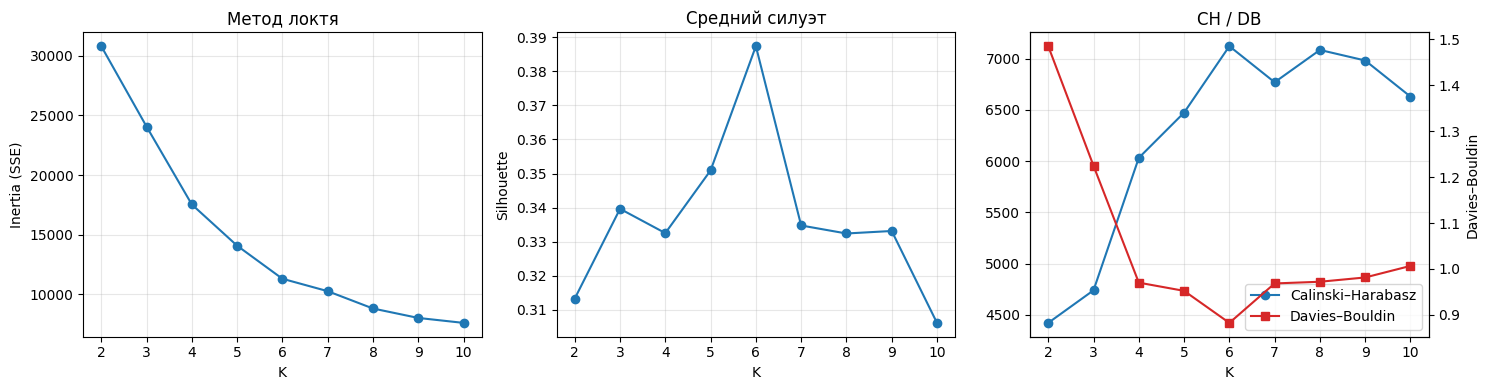

In [136]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

X_clust = df_factors[["Factor1", "Factor2", "Factor3"]].values

Ks = range(2, 11) 
inertias = []
silhouettes = []
ch_scores = []
db_scores = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_clust)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, labels))
    ch_scores.append(calinski_harabasz_score(X_clust, labels))
    db_scores.append(davies_bouldin_score(X_clust, labels))

# --- графики ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) локоть
axes[0].plot(Ks, inertias, marker="o")
axes[0].set_title("Метод локтя")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia (SSE)")
axes[0].grid(alpha=0.3)

# 2) силуэт
axes[1].plot(Ks, silhouettes, marker="o")
axes[1].set_title("Средний силуэт")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette")
axes[1].grid(alpha=0.3)

# 3) Calinski & Davies-Bouldin
axes[2].plot(Ks, ch_scores, marker="o", label="Calinski–Harabasz")
axes[2].set_xlabel("K")
axes[2].set_title("CH / DB")
axes[2].tick_params(axis='y')
axes[2].grid(alpha=0.3)

ax2 = axes[2].twinx()
ax2.plot(Ks, db_scores, marker="s", color="tab:red", label="Davies–Bouldin")
ax2.set_ylabel("Davies–Bouldin")

lines, labels = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[2].legend(lines + lines2, labels + labels2, loc="best")

plt.tight_layout()
plt.show()

Проведем анализ полученных графиков:
- Анализируя график метода локтя видим что после 6 спуск прекращается. Количество кластеров находится в районе 5-6
- По графику среднего силуэта наилучшим вариантом будет k = 6.
- По графику CH/DB CH достигает максимального значения при k = 6, а DB достигает минимального значения так же при k = 6.

Приходим к выводу что наилучшим количеством кластеров будет 6.

### подготовка данных и импорт

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_completeness_v_measure
)
from scipy.spatial.distance import cdist

# Данные для кластеризации (факторное пространство)
X_clust = df_factors[["Factor1", "Factor2", "Factor3"]].values

# Истинные классы фасоли
true_labels = y.astype("category")
true_labels_int = true_labels.cat.codes.values
class_names = true_labels.cat.categories.tolist()

K = 6
print("Форма X_clust:", X_clust.shape)
print("Уникальных классов фасоли:", class_names)


Форма X_clust: (13611, 3)
Уникальных классов фасоли: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


### обучение k-means и визуализация кластеров

=== K-MEANS (K=6) ===
Размеры кластеров:
  кластер 0: 1870 объектов
  кластер 1: 2176 объектов
  кластер 2: 755 объектов
  кластер 3: 5779 объектов
  кластер 4: 2517 объектов
  кластер 5: 514 объектов


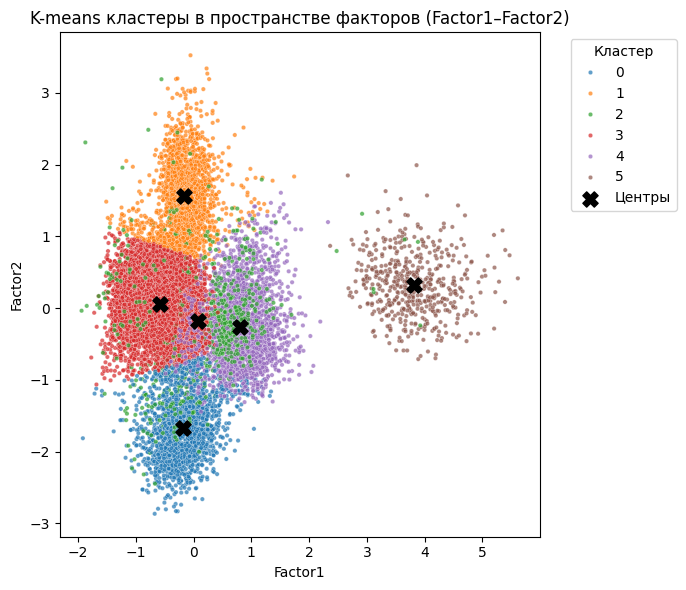

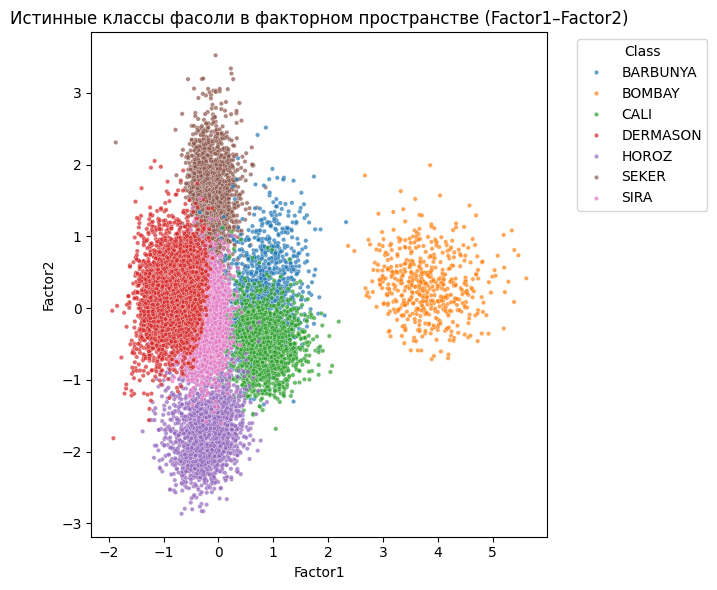

In [138]:
# Обучаем k-means
km = KMeans(n_clusters=K, random_state=42, n_init="auto")
km_labels = km.fit_predict(X_clust)
km_centers = km.cluster_centers_

print("=== K-MEANS (K=6) ===")
print("Размеры кластеров:")
for k in range(K):
    print(f"  кластер {k}: {np.sum(km_labels == k)} объектов")

# ---- График: Factor1–Factor2 цвет = кластер k-means ----
plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=df_factors["Factor1"],
    y=df_factors["Factor2"],
    hue=km_labels,
    palette="tab10",
    s=10,
    alpha=0.7,
    legend="full"
)
plt.scatter(km_centers[:, 0], km_centers[:, 1],
            c="black", s=120, marker="X", label="Центры")
plt.title("K-means кластеры в пространстве факторов (Factor1–Factor2)")
plt.xlabel("Factor1")
plt.ylabel("Factor2")
plt.legend(title="Кластер", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---- Для сравнения: те же факторы, но цвет = настоящий класс ----
plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=df_factors["Factor1"],
    y=df_factors["Factor2"],
    hue=true_labels,
    s=10,
    alpha=0.7,
    legend="full"
)
plt.title("Истинные классы фасоли в факторном пространстве (Factor1–Factor2)")
plt.xlabel("Factor1")
plt.ylabel("Factor2")
plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### силуэты (общий и по кластерам) + силуэт-диаграмма

Средний silhouette:        0.387
Calinski–Harabasz (CH):    7123.2
Davies–Bouldin (DB):       0.883

Средний silhouette по кластерам:
  кластер 0: 0.434
  кластер 1: 0.463
  кластер 2: 0.237
  кластер 3: 0.393
  кластер 4: 0.285
  кластер 5: 0.560


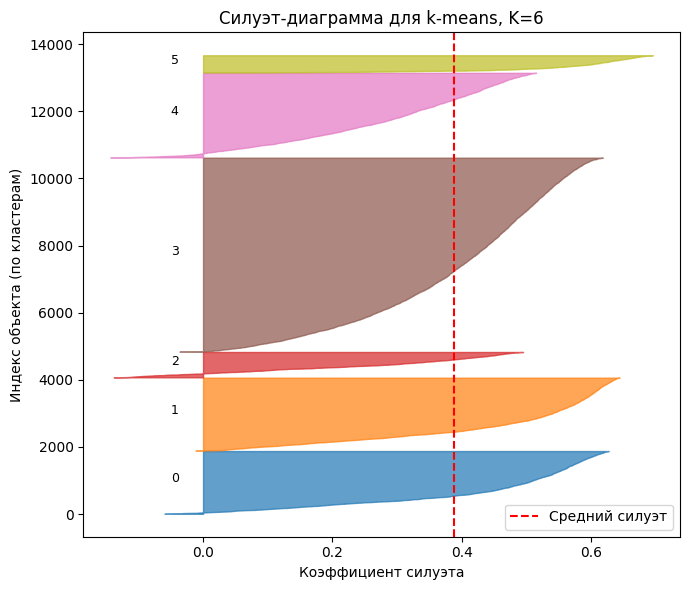

In [139]:
# Общие метрики
km_silhouette = silhouette_score(X_clust, km_labels)
km_ch = calinski_harabasz_score(X_clust, km_labels)
km_db = davies_bouldin_score(X_clust, km_labels)

print(f"Средний silhouette:        {km_silhouette:.3f}")
print(f"Calinski–Harabasz (CH):    {km_ch:.1f}")
print(f"Davies–Bouldin (DB):       {km_db:.3f}")

# Silhouette по объектам и кластерам
sil_values = silhouette_samples(X_clust, km_labels)

print("\nСредний silhouette по кластерам:")
km_sil_by_cluster = []
for k in range(K):
    s_k = sil_values[km_labels == k].mean()
    km_sil_by_cluster.append(s_k)
    print(f"  кластер {k}: {s_k:.3f}")

# ---- Силуэт-диаграмма для K=6 ----
plt.figure(figsize=(7, 6))
y_lower = 10
for k in range(K):
    cluster_sil = np.sort(sil_values[km_labels == k])
    size_k = cluster_sil.shape[0]
    y_upper = y_lower + size_k

    color = plt.cm.tab10(k / K)
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, cluster_sil,
        facecolor=color, edgecolor=color, alpha=0.7
    )
    plt.text(-0.05, y_lower + 0.5 * size_k, str(k), fontsize=9)
    y_lower = y_upper + 10

plt.axvline(x=km_silhouette, color="red", linestyle="--", label="Средний силуэт")
plt.title("Силуэт-диаграмма для k-means, K=6")
plt.xlabel("Коэффициент силуэта")
plt.ylabel("Индекс объекта (по кластерам)")
plt.legend()
plt.tight_layout()
plt.show()


### внутрикластерные расстояния и компактность

In [140]:
# Расстояния объектов до центров
dists_all = cdist(X_clust, km_centers)   # (n_samples, K)
assigned_dists = dists_all[np.arange(X_clust.shape[0]), km_labels]

sse_total = np.sum(assigned_dists**2)
print(f"Общая внутрикластерная сумма квадратов (SSE): {sse_total:.1f}")
print(f"Inertia из k-means (должна совпасть):        {km.inertia_:.1f}")

cluster_stats = []
for k in range(K):
    mask = (km_labels == k)
    d_k = assigned_dists[mask]
    cluster_stats.append({
        "cluster": k,
        "size": mask.sum(),
        "mean_dist": d_k.mean(),
        "std_dist": d_k.std(),
        "sse": np.sum(d_k**2)
    })

km_cluster_stats = pd.DataFrame(cluster_stats)
km_cluster_stats


Общая внутрикластерная сумма квадратов (SSE): 11286.5
Inertia из k-means (должна совпасть):        11286.5


,cluster,size,mean_dist,std_dist,sse
0,0,1870,0.762029,0.374754,1348.509485
1,1,2176,0.644061,0.354450,1176.019073
2,2,755,1.528314,1.051036,2597.518484
3,3,5779,0.668538,0.284462,3050.514139
4,4,2517,0.893125,0.388219,2387.086952
5,5,514,1.050630,0.556959,726.809958


C:\Users\bulch\AppData\Local\Temp\ipykernel_15648\631412756.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=km_cluster_stats, x="cluster", y="mean_dist", palette="tab10")


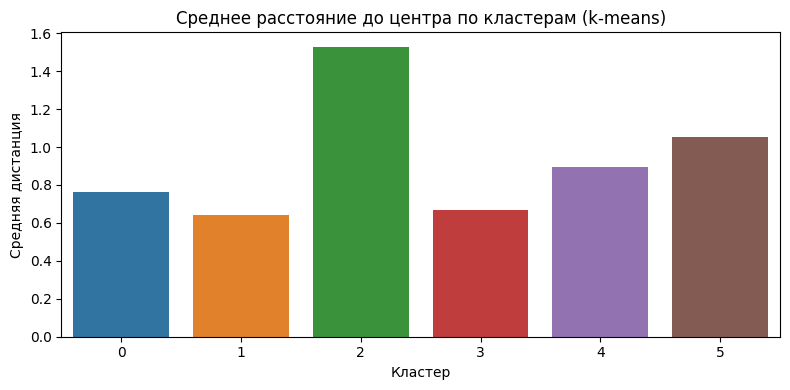

C:\Users\bulch\AppData\Local\Temp\ipykernel_15648\631412756.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=km_cluster_stats, x="cluster", y="size", palette="tab10")


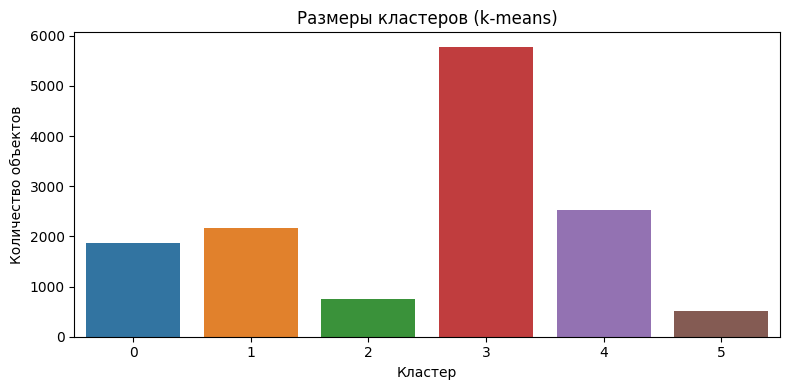

In [141]:
plt.figure(figsize=(8, 4))
sns.barplot(data=km_cluster_stats, x="cluster", y="mean_dist", palette="tab10")
plt.title("Среднее расстояние до центра по кластерам (k-means)")
plt.xlabel("Кластер")
plt.ylabel("Средняя дистанция")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=km_cluster_stats, x="cluster", y="size", palette="tab10")
plt.title("Размеры кластеров (k-means)")
plt.xlabel("Кластер")
plt.ylabel("Количество объектов")
plt.tight_layout()
plt.show()


### расстояния между центрами кластеров (heatmap)

In [142]:
center_dists = cdist(km_centers, km_centers)
km_inter_df = pd.DataFrame(
    center_dists,
    index=[f"C{k}" for k in range(K)],
    columns=[f"C{k}" for k in range(K)]
)
km_inter_df.round(3)


,C0,C1,C2,C3,C4,C5
C0,0.000,3.241,3.571,1.783,1.824,4.468
C1,3.241,0.000,3.646,1.559,2.133,4.173
C2,3.571,3.646,0.000,3.274,2.761,5.053
C3,1.783,1.559,3.274,0.000,1.523,4.405
C4,1.824,2.133,2.761,1.523,0.000,3.139
C5,4.468,4.173,5.053,4.405,3.139,0.000


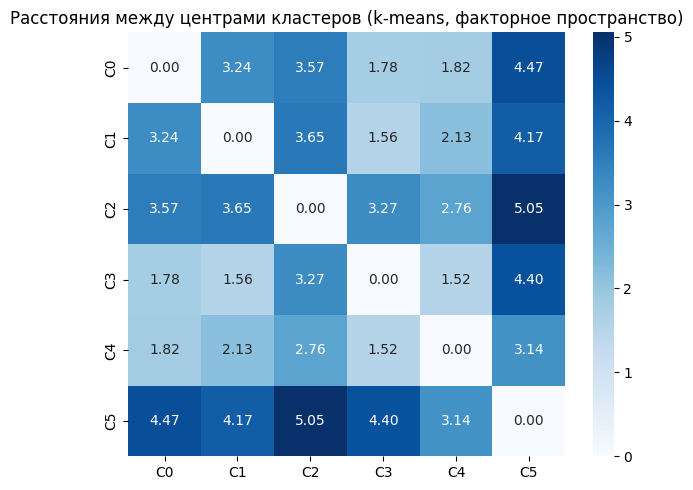

In [143]:
plt.figure(figsize=(6, 5))
sns.heatmap(km_inter_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Расстояния между центрами кластеров (k-means, факторное пространство)")
plt.tight_layout()
plt.show()


### внешние метрики + heatmap «кластеры vs классы фасоли»

In [144]:
# Внешние метрики
km_ari = adjusted_rand_score(true_labels_int, km_labels)
km_nmi = normalized_mutual_info_score(true_labels_int, km_labels)
km_h, km_c, km_v = homogeneity_completeness_v_measure(true_labels_int, km_labels)

print("Внешние метрики (k-means vs Class):")
print(f"ARI (Adjusted Rand Index):    {km_ari:.3f}")
print(f"NMI (Normalized Mutual Info): {km_nmi:.3f}")
print(f"Homogeneity:                  {km_h:.3f}")
print(f"Completeness:                 {km_c:.3f}")
print(f"V-measure:                    {km_v:.3f}")

# Таблица соответствия кластеров и классов
ct = pd.crosstab(km_labels, true_labels)
ct


Внешние метрики (k-means vs Class):
ARI (Adjusted Rand Index):    0.531
NMI (Normalized Mutual Info): 0.631
Homogeneity:                  0.578
Completeness:                 0.694
V-measure:                    0.631


Class,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
row_0,,,,,,,
0,9,0,87,26,1620,0,128
1,49,0,2,204,0,1881,40
2,130,8,265,59,207,15,71
3,33,0,12,3257,41,129,2307
4,1101,0,1264,0,60,2,90
5,0,514,0,0,0,0,0


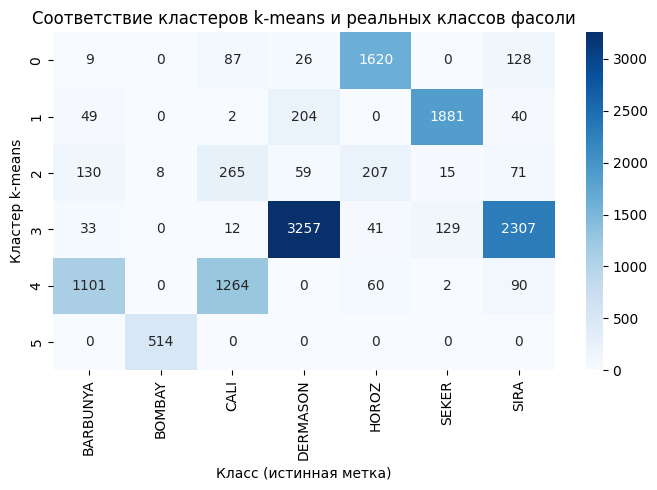

In [145]:
plt.figure(figsize=(7, 5))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("Соответствие кластеров k-means и реальных классов фасоли")
plt.xlabel("Класс (истинная метка)")
plt.ylabel("Кластер k-means")
plt.tight_layout()
plt.show()
